# 00 — PyTorch Warm-up (Week 0)

**Goal:** Dust off PyTorch. Confirm your environment works. Train a tiny model on CIFAR-10 for 5 epochs. Plot the training curve.

**Time:** 60-90 minutes.

**Why this notebook exists:** You said you have decent but rusty PyTorch. The replication itself uses real ResNet training and custom parameter manipulation — both require comfort with PyTorch internals. Better to spend an hour warming up here than to fight syntax errors during the real work in Week 2.

## 0.1 — Environment check

Run this cell first. If anything errors, fix it before continuing.

In [1]:
import sys
import torch
import torchvision
import numpy as np
import matplotlib

print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy:       {np.__version__}")
print(f"Matplotlib:  {matplotlib.__version__}")
print()
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device:    {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU. Training will be slow but doable.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

Python:      3.12.13
PyTorch:     2.2.2
Torchvision: 0.17.2
NumPy:       1.26.4
Matplotlib:  3.10.9

CUDA available: False
Running on CPU. Training will be slow but doable.

Using device: cpu


## 0.2 — Load CIFAR-10

CIFAR-10 is 60,000 small color images (32×32) in 10 classes. About 170 MB, downloaded once and cached.

If the download fails, the data is also available at `https://www.cs.toronto.edu/~kriz/cifar.html`.

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_set = datasets.CIFAR10("../data", train=True,  download=True, transform=transform)
test_set  = datasets.CIFAR10("../data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_set):,}")
print(f"Test samples:     {len(test_set):,}")

100%|███████████████████████| 170498071/170498071 [00:12<00:00, 13673201.70it/s]


Extracting ../data/cifar-10-python.tar.gz to ../data
Files already downloaded and verified
Training samples: 50,000
Test samples:     10,000


## 0.3 — Visualize a few samples

Always look at the data before training a model.

Matplotlib is building the font cache; this may take a moment.


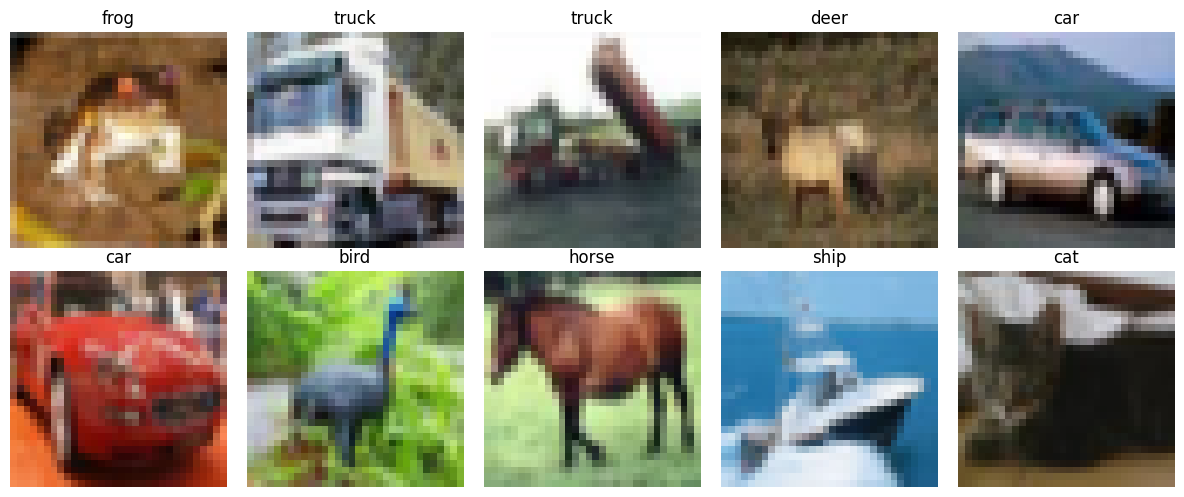

In [3]:
import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Undo the normalization for display
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2470, 0.2435, 0.2616])

def unnormalize(img):
    img = img.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    ax.imshow(unnormalize(img))
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 0.4 — A tiny CNN (NOT the real model)

This is just a warm-up. We'll use ResNet-20 for the real project. This tiny model is to make sure your training loop is working.

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 -> 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 -> 8
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = TinyCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyCNN parameters: {n_params:,}")

TinyCNN parameters: 545,098


## 0.5 — Training loop (5 epochs)

This should take 2-5 minutes on a modern GPU, 15-30 minutes on CPU. If it takes much longer, reduce epochs to 2.

In [5]:
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

EPOCHS = 5

for epoch in range(EPOCHS):
    t0 = time.time()
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss   += loss.item() * x.size(0)
        train_correct += (out.argmax(1) == y).sum().item()
        train_total  += x.size(0)

    # --- Eval ---
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_loss   += criterion(out, y).item() * x.size(0)
            test_correct += (out.argmax(1) == y).sum().item()
            test_total  += x.size(0)

    history["train_loss"].append(train_loss / train_total)
    history["test_loss"].append(test_loss / test_total)
    history["train_acc"].append(train_correct / train_total)
    history["test_acc"].append(test_correct / test_total)

    print(f"Epoch {epoch+1}/{EPOCHS}  "
          f"train_loss={history['train_loss'][-1]:.3f}  "
          f"test_loss={history['test_loss'][-1]:.3f}  "
          f"test_acc={history['test_acc'][-1]:.3f}  "
          f"({time.time()-t0:.1f}s)")

Epoch 1/5  train_loss=1.574  test_loss=1.262  test_acc=0.548  (94.5s)
Epoch 2/5  train_loss=1.131  test_loss=1.060  test_acc=0.628  (94.5s)
Epoch 3/5  train_loss=0.943  test_loss=0.919  test_acc=0.680  (96.9s)
Epoch 4/5  train_loss=0.814  test_loss=0.862  test_acc=0.701  (97.8s)
Epoch 5/5  train_loss=0.709  test_loss=0.825  test_acc=0.717  (96.5s)


## 0.6 — Plot the training curve

Sanity check: did the loss go down? It should. If it didn't, something is wrong.

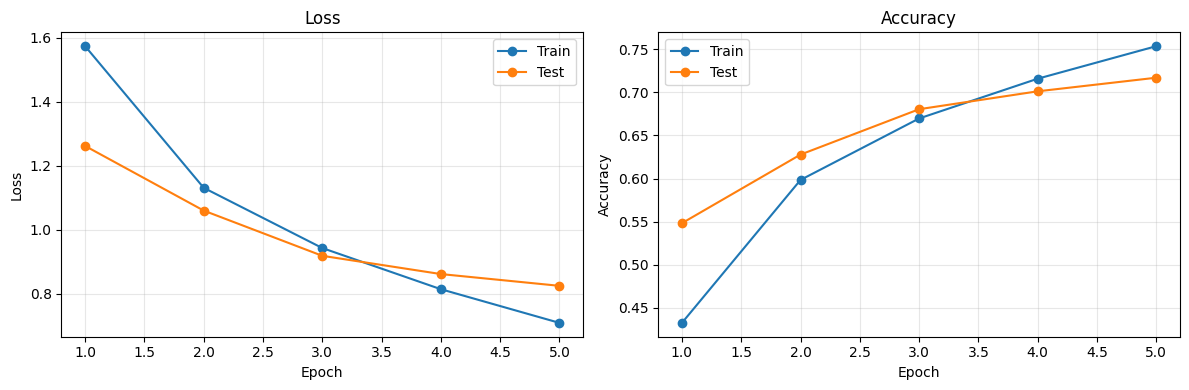


Final test accuracy: 71.7%

Expected: somewhere between 55% and 70% after 5 epochs with this tiny model.
Real ResNet-20 trained for 100 epochs will hit ~91%.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)

ax1.plot(epochs, history["train_loss"], 'o-', label='Train')
ax1.plot(epochs, history["test_loss"], 'o-', label='Test')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history["train_acc"], 'o-', label='Train')
ax2.plot(epochs, history["test_acc"], 'o-', label='Test')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {history['test_acc'][-1]:.1%}")
print("\nExpected: somewhere between 55% and 70% after 5 epochs with this tiny model.")
print("Real ResNet-20 trained for 100 epochs will hit ~91%.")

## 0.7 — You're done with Week 0

If you got here without errors, you're ready for Week 1. 

**Next steps:**
1. Move to `01_understanding_the_paper.ipynb` — read the paper and walk through the math by hand.
2. By end of Week 1, you'll be training the actual ResNet-20 and PlainNet-20.

**Troubleshooting:**
- If training was extremely slow on CPU (>30 min for 5 epochs), consider Google Colab (free GPU) for the real ResNet training.
- If accuracy stayed near 10% (random guessing), check that you're using `optimizer.zero_grad()` before backward and that the loss is being computed correctly.
- If you got CUDA errors, downgrade to CPU mode by changing the device line to `torch.device('cpu')`.